<a href="https://colab.research.google.com/github/akashgardas/Deep-Learning/blob/cnn/notebooks/cnn/MNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST dataset - Digits classification

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical

## Load Dataset

In [ ]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display dataset shapes
print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


## Data Visualization

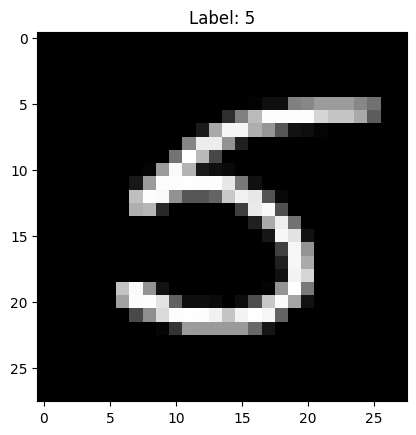

In [ ]:
rand_img = np.random.randint(0, X_train.shape[0])
img = X_train[rand_img, :, :]
label = y_train[rand_img]
plt.imshow(img, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

## Preprocess the data

In [ ]:
# Normalize the pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
# Reshape to include the channel dim
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
# Encode labels - one hot encoding
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

## Build CNN Model

In [ ]:
# Define architecture
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Train Model

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9982 - loss: 0.0052 - val_accuracy: 0.9961 - val_loss: 0.0124
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9989 - loss: 0.0031 - val_accuracy: 0.9973 - val_loss: 0.0090
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9982 - val_loss: 0.0068
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 0.9967 - val_loss: 0.0136
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9982 - val_loss: 0.0078
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9991 - loss: 0.0026 - val_accuracy: 0.9967 - val_loss: 0.0138
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9970 - val_loss: 0.0111
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9990 - loss: 0.0027 - 

## Test Model

In [ ]:
# Test model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'Test accuracy: {test_acc}')
print(f'Test loss: {test_loss}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9887 - loss: 0.0576
Test accuracy: 0.991100013256073
Test loss: 0.04671467840671539


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted label: 9
Actual label: 9


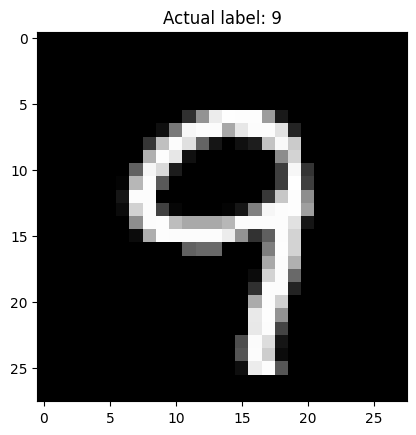

In [ ]:
# Make prediction with random input from the whole dataset
rand_img = np.random.randint(0, X_test.shape[0])
img = X_test[rand_img, :, :]
actual_label = np.argmax(y_test[rand_img])

# Predict label
prediction = model.predict(img.reshape(1, 28, 28, 1))
predicted_label = np.argmax(prediction)
print(f'Predicted label: {predicted_label}')
print(f'Actual label: {actual_label}')

# Visualize image
plt.imshow(img.reshape(28, 28), cmap='gray')
plt.title(f'Actual label: {actual_label}')
plt.show()

## Save Model


In [ ]:
# Save model
model.save('/content/drive/MyDrive/Tek works/Deep-Learning/models/mnist_cnn_tensorflow_model.keras')